# 🚂 TARDIS Project — PREDICTING THE UNPREDICTABLE
***

### The Research Team :
* **Raphaël Permentier**
* **Stan Gaumain**
* **Come Chaslerie**

---
### **Our Mission:** 

**Analyse train database, find out why trains are late, and build a program to predict train delays before they happen.**

---
### **Preliminary Step**

**To do this, we first looked closely at our data. We found some mistakes and missing information. We need to clean and fix these problems before we can build our prediction models.**

---
##### **First, we load the file containing the database so that we can modify it :**

In [950]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#load all mendatory lib

#put name of the file in filepath variable
filepath = "dataset.csv"
#load the file in variable df (Dataframe)
df = pd.read_csv(filepath, sep=";")

# 🧼 **CLEANING THE DATASET** #

---
### **Cleaning the Dataset**
---

To clean our data, we follow these simple steps:

* **1. Fix Data Types** We change each column to the right type. For example, we convert text into numbers so the computer can read them correctly.

* **2. Delete aberrant values** We remove aberrant values.
  
* **3. Remove Broken Rows** We delete rows that are missing important information because we cannot use them.
  
* **4. Fill Empty Spaces** If some columns have missing values, we fill them with 0, None or an average number.
  
* **5. Clean Extra Spaces** We remove invisible spaces at the beginning and the end of text columns (like station names) so they match perfectly.
  
* **6. Create New Columns** We build new information (features) from our data to help our prediction models work better later.

* **7. Delete Useless Columns** We remove text columns (like comments) that we do not need for our machine learning models.

* **8. Export Cleaned Dataset** We save our final, perfectly clean data into a new CSV file.
---

### ♻️ **Step 1 : Convert all columns to the appropriate type :**

**the columns type before :**

In [951]:
#print all columns type
print(df.dtypes)

Date                                                                             str
Service                                                                          str
Departure station                                                                str
Arrival station                                                                  str
Average journey time                                                             str
Number of scheduled trains                                                       str
Number of cancelled trains                                                       str
Cancellation comments                                                            str
Number of trains delayed at departure                                            str
Average delay of late trains at departure                                        str
Average delay of all trains at departure                                         str
Departure delay comments                                         

⚠️ **The Problem:**
Right now, some columns have the wrong data type. This will cause errors when we try to use the data in our models.

💡 **Our Fix:**
We write code to fix this. It automatically changes text columns into strings and number columns into numbers.

In [952]:
cols_to_num = [
    'Average journey time', 
    'Number of scheduled trains',
    'Number of cancelled trains',
    'Number of trains delayed at departure',
    'Average delay of late trains at departure',
    'Average delay of all trains at departure',
    'Number of trains delayed at arrival',
    'Average delay of late trains at arrival',
    'Average delay of all trains at arrival',
    'Number of trains delayed > 15min',
    'Average delay of trains > 15min (if competing with flights)',
    'Number of trains delayed > 30min',
    'Number of trains delayed > 60min',
    'Pct delay due to external causes',
    'Pct delay due to infrastructure',
    'Pct delay due to traffic management',
    'Pct delay due to rolling stock',
    'Pct delay due to station management and equipment reuse',
    'Pct delay due to passenger handling (crowding, disabled persons, connections)'
]

cols_to_string = [
    'Service',
    'Departure station',
    'Arrival station',
    'Cancellation comments',
    'Departure delay comments',
    'Arrival delay comments'
]

#repeats the transformation for each column of the "cols_to_num" list
for col_num in cols_to_num:
    #convert columns to a str type
    df[col_num] = df[col_num].astype("string")
    #replace all ',' to '.' to transform into numeric
    df[col_num] = df[col_num].str.replace(',', '.')
    #Remove all the "min" characters so that you can then convert to numeric without any problems.
    df[col_num] = df[col_num].str.replace(' min', '')
    #Remove all the "%" characters so that you can then convert to numeric without any problems.
    df[col_num] = df[col_num].str.replace('%', '')
    #Converted the column to numeric type (string to numeric)
    df[col_num] = pd.to_numeric(df[col_num], errors='coerce')
for col_str in cols_to_string:
    #convert columns to a str type
    df[col_str] = df[col_str].astype("string")
#convert columns 'Date' to a datetime type with format year-month
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m', errors='coerce')
#Keep only the months and years to ensure the data has the same format.
df['Date'] = df['Date'].dt.to_period('M')

**The columns type after conversion :**

In [953]:
print(df.dtypes)

Date                                                                             period[M]
Service                                                                             string
Departure station                                                                   string
Arrival station                                                                     string
Average journey time                                                               Float64
Number of scheduled trains                                                         Float64
Number of cancelled trains                                                         Float64
Cancellation comments                                                               string
Number of trains delayed at departure                                              Float64
Average delay of late trains at departure                                          Float64
Average delay of all trains at departure                                           Float64

**We can observe that the column types are now adapted and are therefore easier to use in our models later.**

---

### 🗑️ **Step 2 : Delete aberrant values :**

***

**Find all aberrant values and analyze them to determine how to handle them because these values ​​may cause models to fail.** 



***
**We create a function to generate a graph that will allow us to see the impact of our cleaning on this step**

In [954]:
sns.set_theme(style="whitegrid")

def plot_delay_dispersion(dataset, graph, couleur, label, axe_x, axe_y):
    sns.scatterplot(
        data=dataset, 
        x = axe_x, 
        y = axe_y,
        color = couleur, 
        alpha = 0.6,
        label = label,
        ax = graph
    )
    graph.set_xlabel(axe_x)
    graph.set_ylabel(axe_y)


def scatterplot_graphique(df_before, df_after, title, axe_x, axe_y):
    df_removed = df_before.drop(index=df_after.index, errors='ignore')
    fig, ax = plt.subplots(figsize=(10, 6))
    plot_delay_dispersion(df_removed, ax, "#e74c3c", "deleted points", axe_x, axe_y)
    plot_delay_dispersion(df_after, ax, "#2ecc71", "kept points", axe_x, axe_y)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

In [955]:
def point_graph(df, graph, couleur, label):
    var_Y = df['Number of scheduled trains'] - df['Number of cancelled trains'] - df['Number of trains delayed at departure']
    sns.scatterplot(
        data=df, 
        y = var_Y, 
        x = var_Y.index,
        color = couleur, 
        alpha = 0.6,
        label = label,
        ax = graph
    )
    graph.set_xlabel("index df")
    graph.set_ylabel("graph number of scheduled - cancel train - delayed train")

def invalid_nb_cancel_graph(old_df, df):
    df_removed = old_df.drop(index=df.index, errors='ignore')
    fig, ax = plt.subplots(figsize=(10, 6))
    point_graph(df_removed, ax, "#e74c3c", "deleted points")
    point_graph(df, ax, "#2ecc71", "kept points")
    ax.set_title("graph number of scheduled - cancel train - delayed train")
    plt.ylim(top=20)
    plt.axhline(y=0, color='red', linewidth=3)
    plt.show()

In [956]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def point_graph_delays(dataset, graph, couleur, label):
    diff1 = dataset['Number of trains delayed at arrival'] - dataset['Number of trains delayed > 15min']
    diff2 = dataset['Number of trains delayed > 15min'] - dataset['Number of trains delayed > 30min']
    diff3 = dataset['Number of trains delayed > 30min'] - dataset['Number of trains delayed > 60min']
    var_Y = pd.concat([diff1, diff2, diff3], axis=1).min(axis=1)
    sns.scatterplot(
        data=dataset, 
        y=var_Y, 
        x=var_Y.index,
        color=couleur, 
        alpha=0.6,
        label=label,
        ax=graph
    )
    graph.set_xlabel("index df")
    graph.set_ylabel("discrepancy on the delays)")
    
def invalid_delay_graph(old_df, current_df):
    df_removed = old_df.drop(index=current_df.index, errors='ignore')
    fig, ax = plt.subplots(figsize=(10, 6))
    point_graph_delays(df_removed, ax, "#e74c3c", "delete line")
    point_graph_delays(current_df, ax, "#2ecc71", "kept line")
    ax.set_title("delay logic check")
    plt.ylim(top=20) 
    plt.axhline(y=0, color='red', linewidth=3)
    plt.show()

***
**We will generate an initial graph to observe the values ​​we find to be aberrant.**

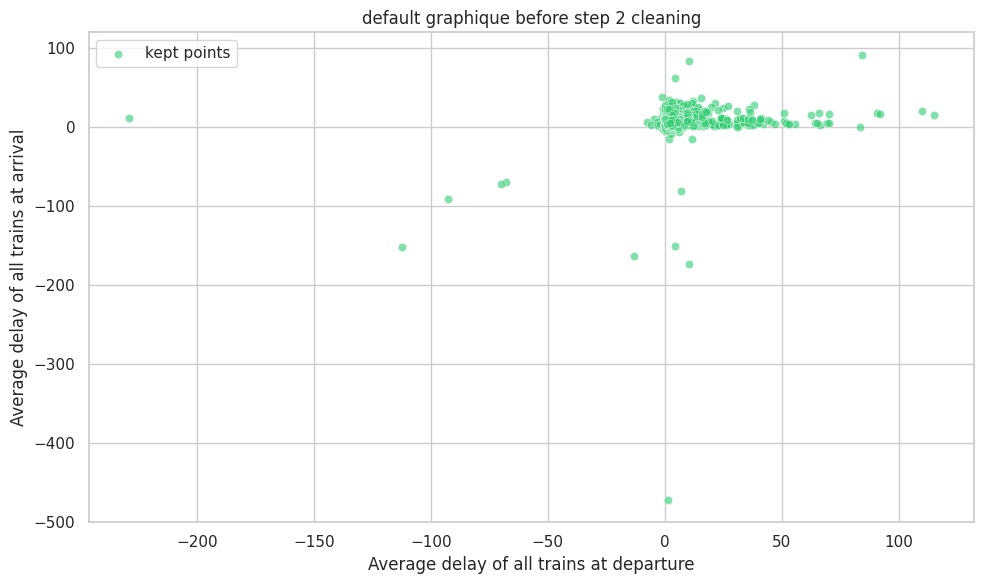

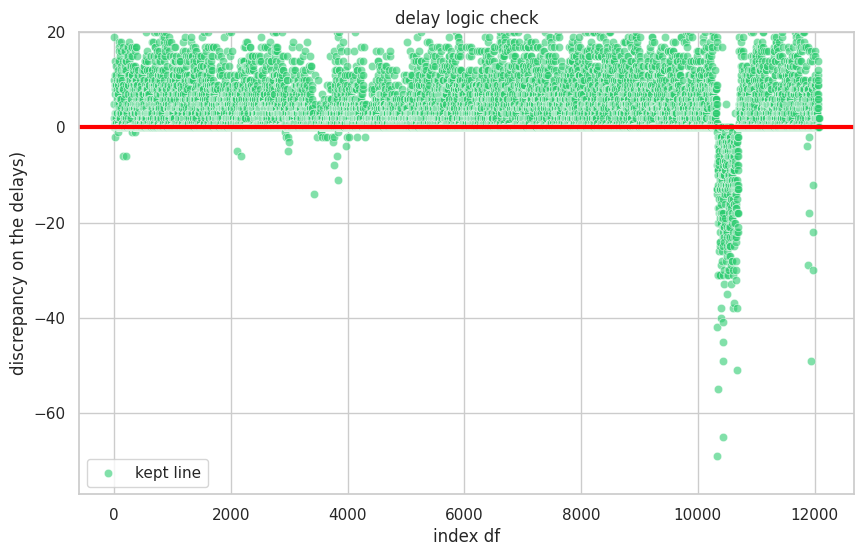

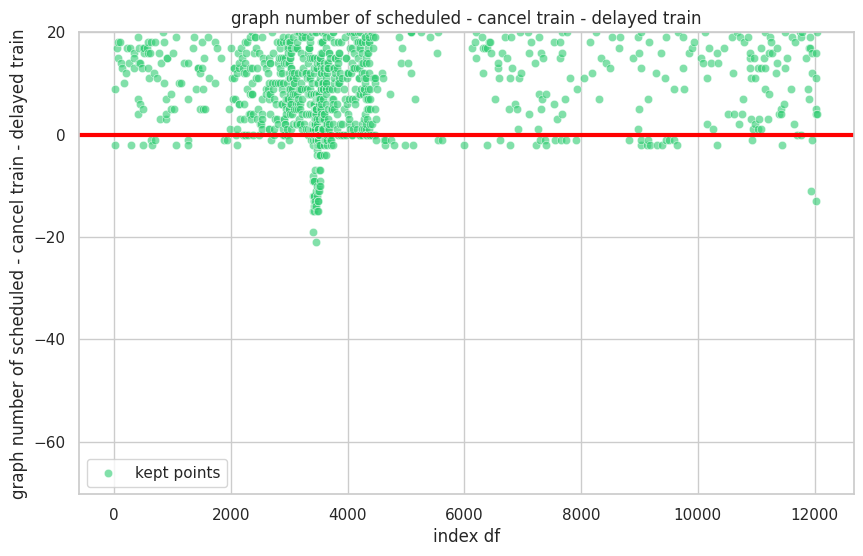

In [957]:
scatterplot_graphique(df, df, "default graphique before step 2 cleaning", "Average delay of all trains at departure", "Average delay of all trains at arrival")
invalid_delay_graph(df, df)
invalid_nb_cancel_graph(df, df)

In [958]:
def point_graph(df, graph, couleur, label):
    var_Y = df['Number of scheduled trains'] - df['Number of cancelled trains'] - df['Number of trains delayed at departure']
    sns.scatterplot(
        data=df, 
        y = var_Y, 
        x = var_Y.index,
        color = couleur, 
        alpha = 0.6,
        label = label,
        ax = graph
    )
    graph.set_xlabel("index df")
    graph.set_ylabel("graph number of scheduled - cancel train - delayed train")

def invalid_nb_cancel_graph(old_df, df):
    df_removed = old_df.drop(index=df.index, errors='ignore')
    fig, ax = plt.subplots(figsize=(10, 6))
    point_graph(df_removed, ax, "#e74c3c", "deleted points")
    point_graph(df, ax, "#2ecc71", "kept points")
    ax.set_title("graph number of scheduled - cancel train - delayed train")
    plt.ylim(top=20)
    plt.axhline(y=0, color='red', linewidth=3)
    plt.show()

***

**We find some impossible values :**

* **Average journey time < 1**

* **negative number in delayed train columns**

* **Invalid train counts**

* **Invalid logic delay trains**

#### **Handle the negative number in delayed train columns :**
**We create a function that checks if the value of each column in the "negative_delay" list is negative. If so, we delete the corresponding row, because a negative value is impossible in that column (for example: a negative number of trains).**

In [959]:
#list of all columns about delay train
negative_delay = [
    'Number of trains delayed at departure',
    'Average delay of late trains at departure',
    'Average delay of all trains at departure',
    'Number of trains delayed at arrival',
    'Average delay of late trains at arrival',
    'Average delay of all trains at arrival',
    'Number of trains delayed > 15min',
    'Average delay of trains > 15min (if competing with flights)',
    'Number of trains delayed > 30min',
    'Number of trains delayed > 60min'
]

def negative_delay_func(line, index, negative_list):
    # Loop for each column in negative_delay
    for col in negative_delay:
        value = line[col]
        # If the value exists and is less than 0
        if pd.notna(value) and value < 0:
            # Add the line index to our deletion list
            negative_list.append(index)
            # Stop checking this line to save time
            break


***
#### **Handle Average journey time < 1 or > 550 :**
**We create a function that checks if the value in the "Average journey time" column is less than 1 or greater than 600 because during the analysis of the graph previously, we saw that some values ​​are in these ranges and are aberrantly different from other values ​​(absurdly higher or lower).**

In [960]:
def wrong_average_journey(line, index, average_journey_list):
    # Extract the average journey time for this row
    value = line['Average journey time']
    # If the time exists and is less than 1
    if pd.notna(value) and (value < 1 or value > 550):
        # Add the row index to our deletion list
        average_journey_list.append(index)

***
#### **Invalid train counts :**
**We are verifying the accuracy of the number of canceled and delayed trains because we noticed that at certain times there are more canceled trains than originally scheduled trains, which is impossible. Therefore, we are creating a function to check this and removing the column if the values ​​are impossible.**

In [961]:
def invalid_train_count(line, index, invalid_count_list):
    # Extract the train counts for scheduled, cancelled and delayed
    scheduled = line['Number of scheduled trains']
    cancelled = line['Number of cancelled trains']
    delayed = line['Number of trains delayed at departure']
    # Verify that all three values actually exist (not empty)
    if pd.notna(scheduled) and pd.notna(cancelled) and pd.notna(delayed):
        # If there are more delayed or cancelled trains than scheduled
        if (scheduled - delayed - cancelled < 0):
            # Add the line index to our deletion list
            invalid_count_list.append(index)

***
#### **Invalid logic delay trains :**
**We are verifying the accuracy of the number of trains delayed by a certain amount because we noticed that at certain times there are more trains delayed by 30 minutes or more than trains delayed by 10 minutes or more, which is impossible since a train delayed by 30 minutes is also delayed by more than 10 minutes. We are creating a function to detect this and we are removing the line if the value is impossible.**

In [962]:
def invalid_delay_logic(line, index, invalid_logic_list):
    # Extract the counters for each delay
    delayed = line['Number of trains delayed at arrival']
    delayed_15 = line['Number of trains delayed > 15min']
    delayed_30 = line['Number of trains delayed > 30min']
    delayed_60 = line['Number of trains delayed > 60min']
    if pd.notna(delayed) and pd.notna(delayed_15) and (delayed_15 > delayed):
        invalid_logic_list.append(index)
        return
    if pd.notna(delayed_15) and pd.notna(delayed_30) and (delayed_30 > delayed_15):
        invalid_logic_list.append(index)
        return
    if pd.notna(delayed_30) and pd.notna(delayed_60) and (delayed_60 > delayed_30):
        invalid_logic_list.append(index)
        return

***
#### **Too hight value delay:**
**We noticed that some lag values ​​are aberrantly high. We chose to remove these values ​​to standardize our data and avoid skewing the model if it takes on an extremely high value when it's just a very specific case or an error during data entry.**

In [963]:
def too_high_value(line, index, hight_value_list):
    start = line['Average delay of all trains at departure']
    end = line['Average delay of all trains at arrival']
    if pd.notna(start) and pd.notna(end):
        if (start > 80) or (end > 40):
            hight_value_list.append(index)


**We apply all the created functions to a loop that calls the functions on each line to check the reliability of the information on that line and whether we can keep it or not; then we delete all the non-essential information.**

In [964]:
# Initialize empty lists to store the indexes of bad lines for each error type
deleted_line = []
negative_list = []
average_journey_list = []
invalid_count_list = []
invalid_logic_list = []
hight_value_list = []
# Main Loop: check every line in the dataset one by one
for index in df.index:
    # Extract the current line data
    line = df.loc[index]
    # Run Test 1: Check for negative delays
    negative_delay_func(line, index, negative_list)
    # Run Test 2: Check for journey times less than 1 minute
    wrong_average_journey(line, index, average_journey_list)
    # Run Test 3: Check for impossible train counts
    invalid_train_count(line, index, invalid_count_list)
    invalid_delay_logic(line, index, invalid_logic_list)
    too_high_value(line, index, hight_value_list)

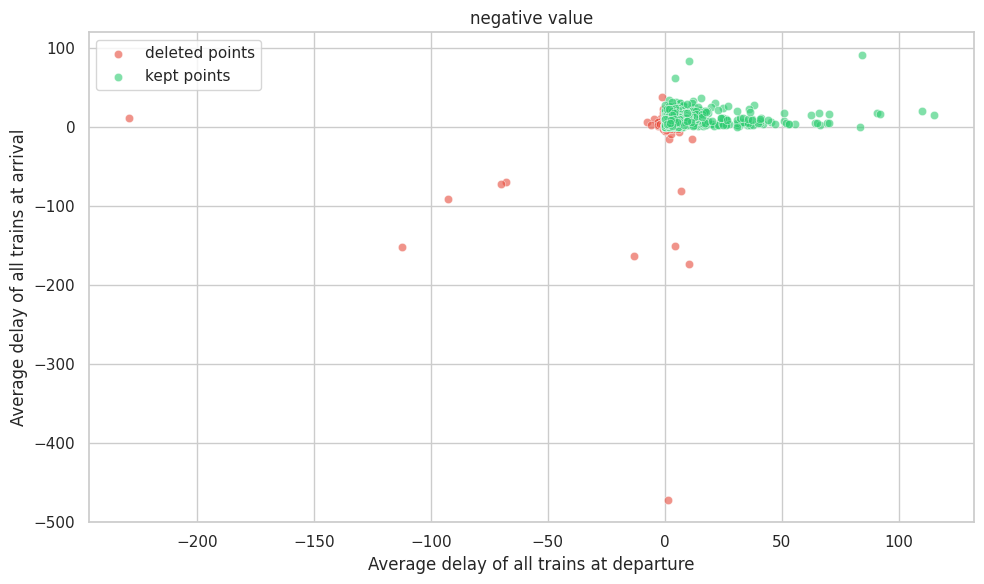

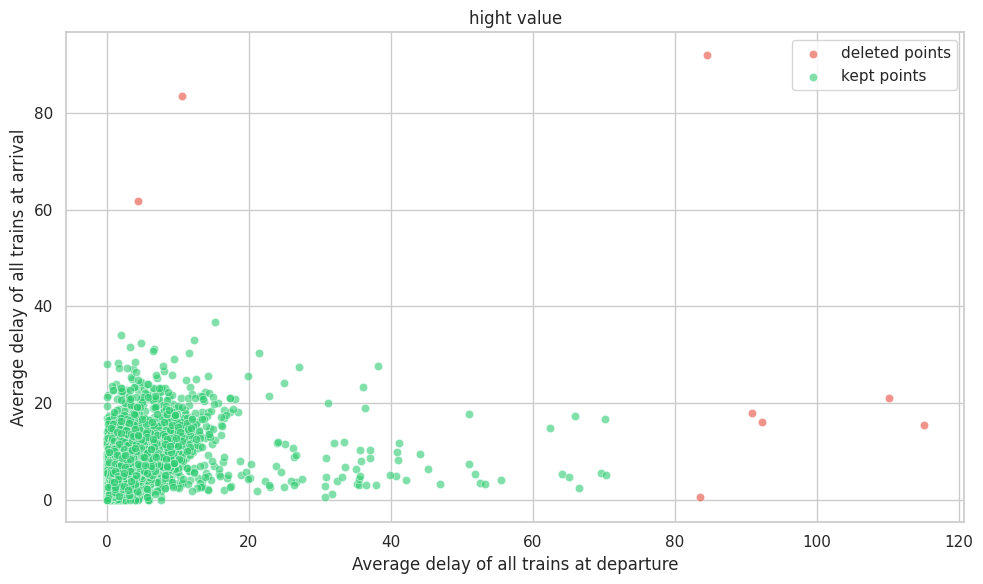

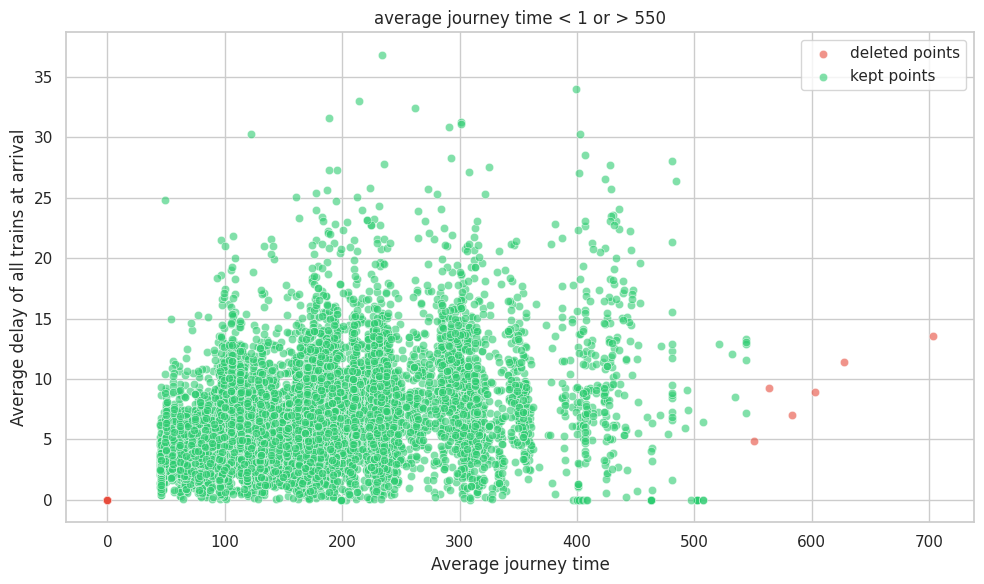

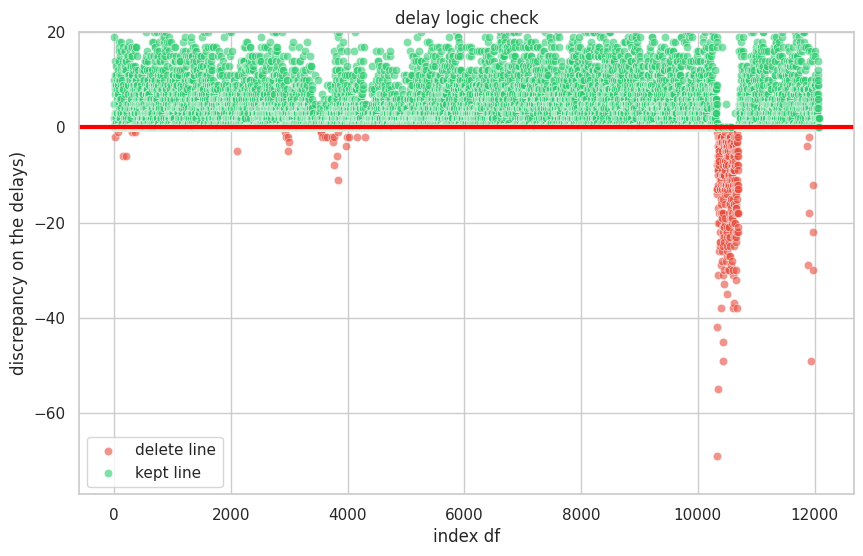

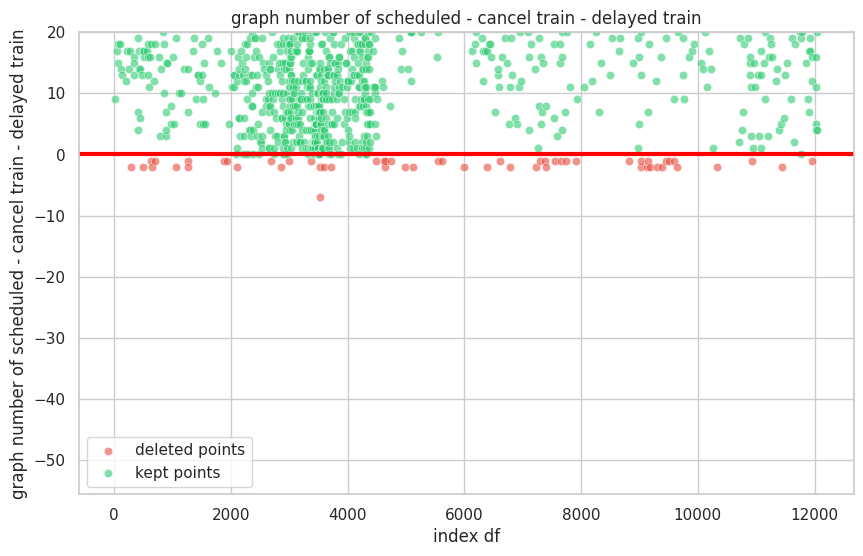

In [965]:
# Delete all the bad lines from the dataset at once
old_df = df
df = df.drop(index=negative_list, errors='ignore')
scatterplot_graphique(old_df, df, "negative value", "Average delay of all trains at departure", "Average delay of all trains at arrival")
old_df = df
df = df.drop(index=hight_value_list, errors='ignore')
scatterplot_graphique(old_df, df, "hight value", "Average delay of all trains at departure", "Average delay of all trains at arrival")
old_df = df
df = df.drop(index=average_journey_list, errors='ignore')
scatterplot_graphique(old_df, df, "average journey time < 1 or > 550", "Average journey time", "Average delay of all trains at arrival")
old_df = df
df = df.drop(index=invalid_logic_list, errors='ignore')
invalid_delay_graph(old_df, df)
old_df = df
df = df.drop(index=invalid_count_list, errors='ignore')
invalid_nb_cancel_graph(old_df, df)

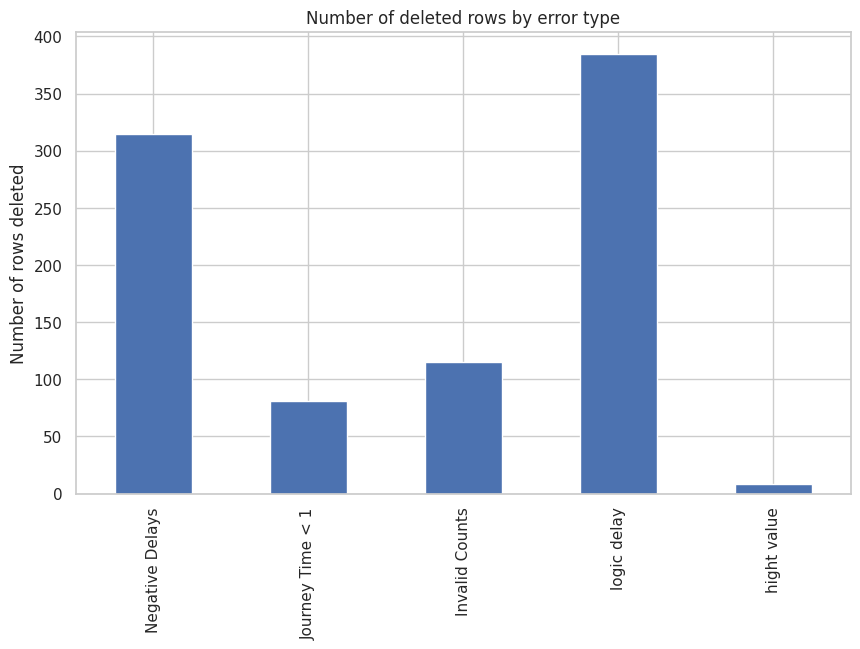

In [966]:
#Calculate the length (number of errors) for each list
len_negative = len(negative_list)
len_journey = len(average_journey_list)
len_invalid = len(invalid_count_list)
len_logic = len(invalid_logic_list)
len_hight = len(hight_value_list)
#Create a Pandas Series with our data and labels
data = pd.Series({'Negative Delays': len_negative, 'Journey Time < 1': len_journey, 'Invalid Counts': len_invalid, 'logic delay': len_logic, 'hight value': len_hight})
#Create the graphic structure (width: 10, height: 6)
plt.figure(figsize=(10, 6))
#select bar graphic style
data.plot(kind='bar')
#Add titles and labels to make it clear
plt.title("Number of deleted rows by error type")
#Add label to the y axe
plt.ylabel("Number of rows deleted")
#Show the graphic
plt.show()

**Result:** The graph shows that the rows with aberrant values have been correctly removed for each case. Our code worked as expected!

### 🗑️ **Step 3 : remove unsable line :**

**The number of line before delete unsable line :**

In [967]:
#list of columns that are designated as mandatory (if a value is null in one of these columns it is unusable)
mandatory_data = [
    'Date',
    'Departure station',
    'Arrival station',
    'Average journey time'
]
#put in nb_line_before the number of line of df
old_df = df
mandatory_data = ['Date', 'Departure station', 'Arrival station', 'Average journey time']
df = df.dropna(subset=mandatory_data)
df = df.drop_duplicates()

The number of line after delete unsable line :

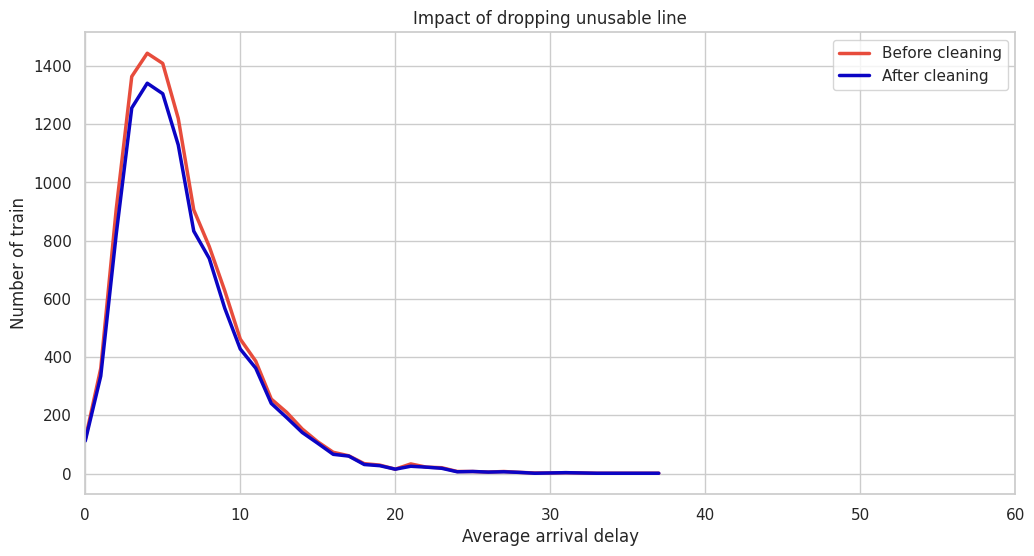

In [968]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
counts_before = old_df['Average delay of all trains at arrival'].round().value_counts()
counts_after = df['Average delay of all trains at arrival'].round().value_counts()
plt.figure(figsize=(12, 6))
sns.lineplot(
    x=counts_before.index, 
    y=counts_before.values, 
    color='#e74c3c', 
    linewidth=2.5,
    label='Before cleaning'
)
sns.lineplot(
    x=counts_after.index, 
    y=counts_after.values, 
    color='#0b04c4', 
    linewidth=2.5,
    label='After cleaning'
)
plt.title("Impact of dropping unusable line")
plt.xlabel("Average arrival delay")
plt.ylabel("Number of train")
plt.xlim(0, 60) 
plt.legend()
plt.show()

**Result:** The chart shows that the broken rows were successfully removed. Our code worked correctly!

***
### 🩹 **Step 4 : Handling all null or missing values :**

**Our Strategy :** Not all missing values (NaN) should be treated the same way. We use different rules depending on the column :

* **Text Columns:** We replace missing comments with `"None"` so we know there was no comment.
* **Number Columns:** We replace missing counts or percentages with `0` because it means nothing happened.
* **Journey Time:** We replace missing times with the **median** (the middle value). This fixes the empty spaces without changing the overall statistics.

Number of null values ​​in each column before :

<function matplotlib.pyplot.show(close=None, block=None)>

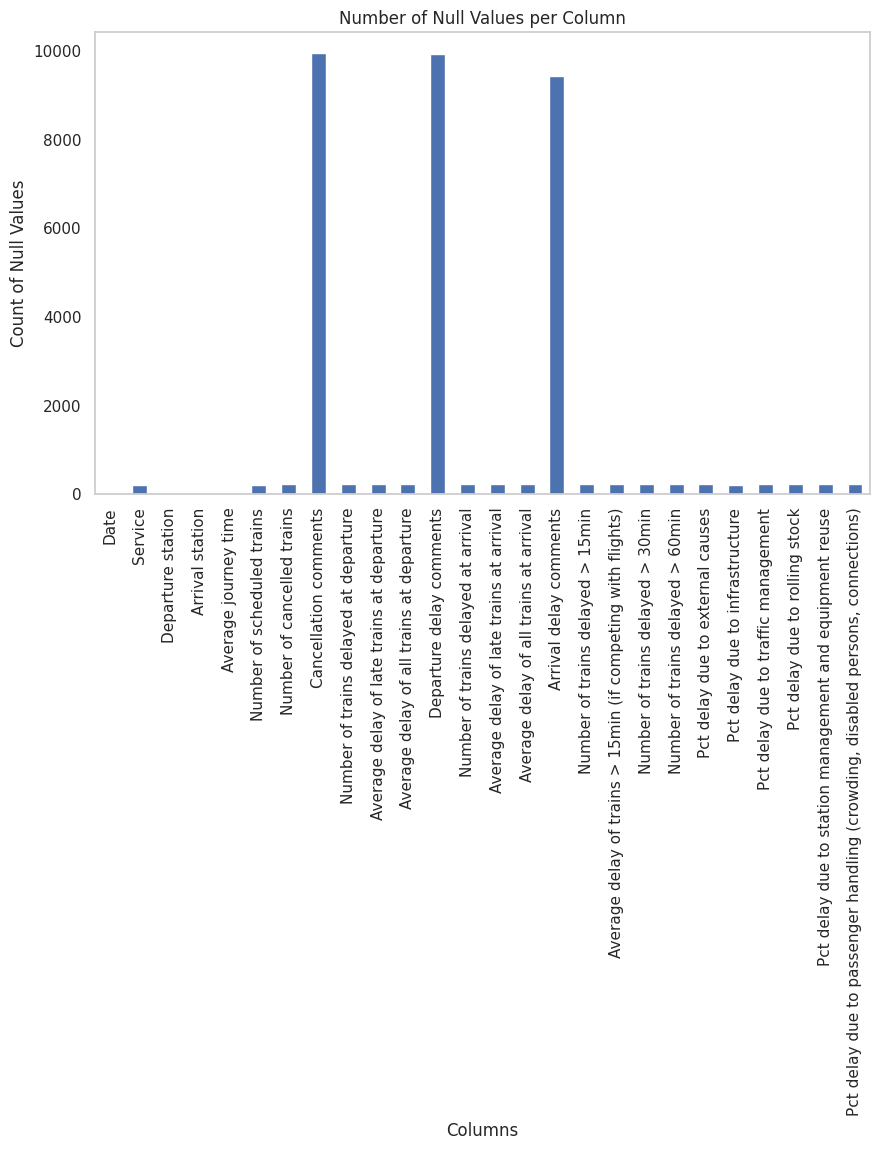

In [969]:
null_counts = df.isnull().sum()
plt.figure(figsize=(10, 6))
null_counts.plot(kind='bar')
plt.title("Number of Null Values per Column")
plt.xlabel("Columns")
plt.ylabel("Count of Null Values")
plt.grid(False)
plt.ylim(0)
plt.show

In [970]:
null_val_to_zero = [
    'Number of scheduled trains',
    'Number of cancelled trains',
    'Number of trains delayed at departure',
    'Average delay of late trains at departure',
    'Average delay of all trains at departure',
    'Number of trains delayed at arrival',
    'Average delay of late trains at arrival',
    'Average delay of all trains at arrival',
    'Number of trains delayed > 15min',
    'Average delay of trains > 15min (if competing with flights)',
    'Number of trains delayed > 30min',
    'Number of trains delayed > 60min',
    'Pct delay due to external causes',
    'Pct delay due to infrastructure',
    'Pct delay due to traffic management',
    'Pct delay due to rolling stock',
    'Pct delay due to station management and equipment reuse',
    'Pct delay due to passenger handling (crowding, disabled persons, connections)'
]

#replaces all null values ​​in the "cols_to_string" list with "None"
df[cols_to_string] = df[cols_to_string].fillna("None")
#replaces all null values ​​in the "null_val_to_zero" list with "0"
df[null_val_to_zero] = df[null_val_to_zero].fillna(0)
#recovery of median travel time
median_val = df['Average journey time'].median()
#Replacing null values ​​in the "Average journey time" column with the median value allows the rows to be used without impacting the average journey time result.
df['Average journey time'] = df['Average journey time'].fillna(median_val)

**Number of null values ​​in each column after :**

<function matplotlib.pyplot.show(close=None, block=None)>

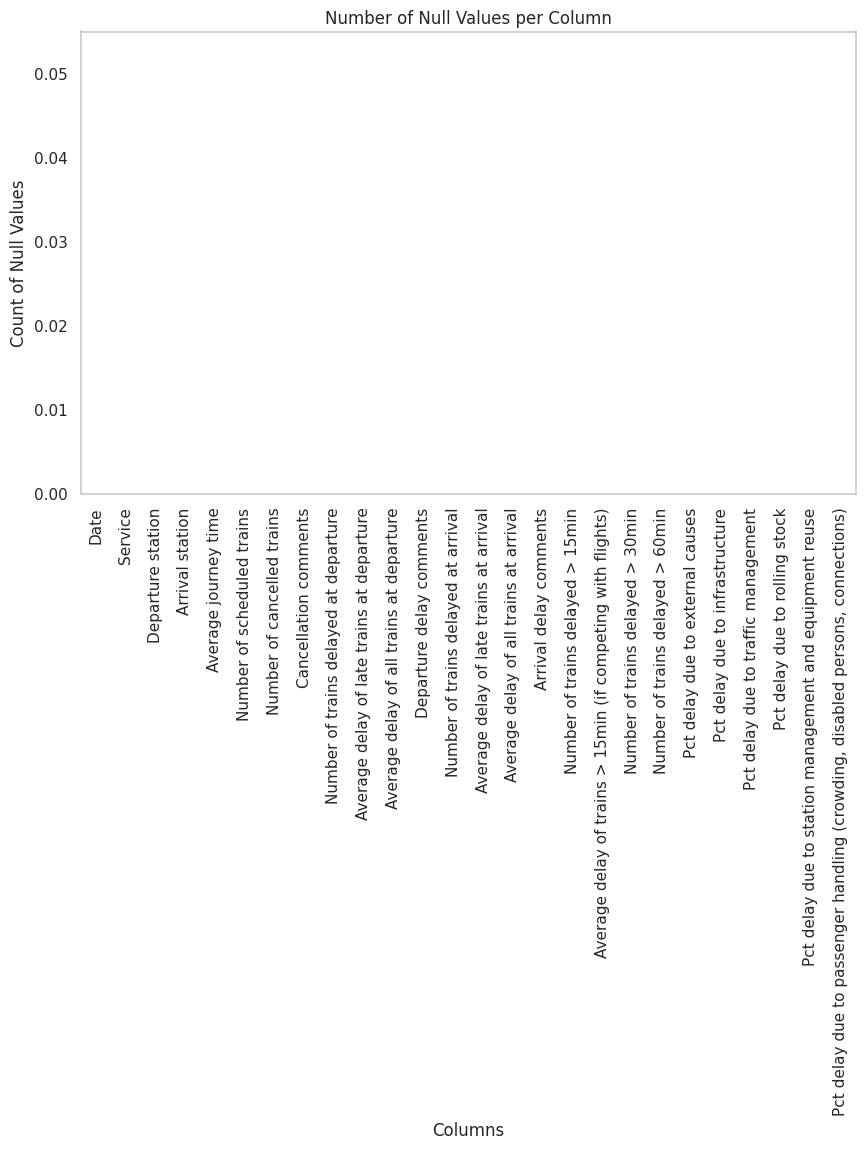

In [971]:
null_counts = df.isnull().sum()
plt.figure(figsize=(10, 6))
null_counts.plot(kind='bar')
plt.title("Number of Null Values per Column")
plt.xlabel("Columns")
plt.ylabel("Count of Null Values")
plt.grid(False)
plt.ylim(0)
plt.show

**Result:** we now have no null values !

***
## 🧹 Step 5: Clean Extra Spaces
***

### **Our Strategy:**
**Sometimes, text columns like station names have invisible spaces at the beginning or the end (for example: `" PARIS LYON "` instead of `"PARIS LYON"`).** 
**We use the `.str.strip()` command to remove these hidden spaces so the text matches perfectly.**

In [972]:
old_df = df.copy()
# Remove invisible spaces from the 'Service' column
df['Service'] = df['Service'].str.strip().str.upper()
# Remove invisible spaces from the 'Departure station' column
df['Departure station'] = df['Departure station'].str.strip().str.upper()
# Remove invisible spaces from the 'Arrival station' column
df['Arrival station'] = df['Arrival station'].str.strip().str.upper()

<Figure size 1000x600 with 0 Axes>

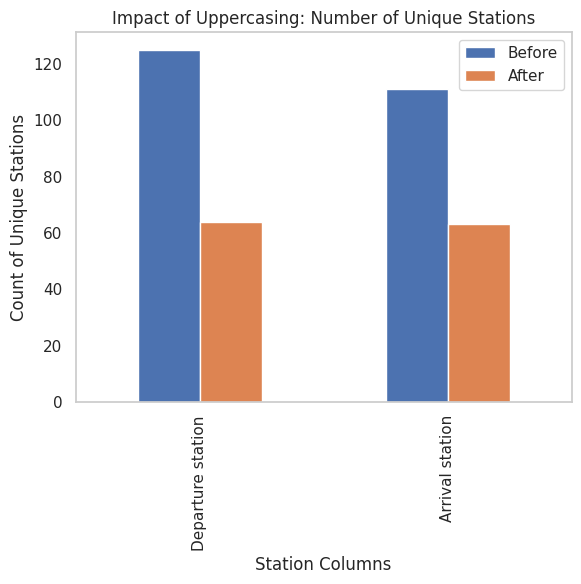

In [973]:
import matplotlib.pyplot as plt
import pandas as pd

data = pd.DataFrame({
    'Before': old_df[['Departure station', 'Arrival station']].nunique(),
    'After': df[['Departure station', 'Arrival station']].nunique()
})
plt.figure(figsize=(10, 6))
data.plot(kind='bar')
plt.title("Impact of Uppercasing: Number of Unique Stations")
plt.xlabel("Station Columns")
plt.ylabel("Count of Unique Stations")
plt.grid(False)
plt.show()

***
## 🏗️ Step 6: Create New Columns
***

### **Our Strategy:**
**To help our future prediction models, we extract new information from the `Date` column: the month, the year, and the quarter.**
**We also create a `delay_category` column by rounding the arrival delays to the nearest minute.**

In [974]:
# Extract the month number from the Date column
df['Month'] = df['Date'].dt.month
# Extract the year number from the Date column
df['Year'] = df['Date'].dt.year
# Extract the quarter number (1 to 4) from the Date column
df['semester'] = df['Date'].dt.quarter
# Round the arrival delay to create a category column
df['delay_category'] = df['Average delay of all trains at arrival'].round()
#create route columns
df['route'] = df['Departure station'] + '-' + df['Arrival station']

***
## 🗑️ Step 7: Delete Useless Columns
***

### **Our Strategy:**
**The comment columns contain too much text and are not useful for our prediction models. We delete them to keep our dataset clean and lightweight.**

In [975]:
columns_to_delete = [
   'Arrival delay comments',
   'Cancellation comments',
   'Departure delay comments'
]

# Drop the selected columns from the dataset
df = df.drop(columns_to_delete, axis=1)

***
## 💾 Step 8: Export Cleaned Dataset
***

### **Final Result:**
**Our data is now perfectly clean with no missing values and the correct types. We save the final dataset into a new CSV file called `cleaned_dataset.csv`.**

In [976]:
# Name of the output file
output_file = "cleaned_dataset.csv"
# Save the clean dataframe to a CSV file without the index column
df.to_csv(output_file, index=False)
# Print the final summary of the dataset (types and row count)

***

# 🧼 **DATA ANALYSE** #

---
### **analyse the dataset with some graphics**
---

list of graphics :

* **1. Fix Data Types** We change each column to the right type. For example, we convert text into numbers so the computer can read them correctly.

* **2. Delete aberrant values** We remove aberrant values.
  
* **3. Remove Broken Rows** We delete rows that are missing important information because we cannot use them.
  
* **4. Fill Empty Spaces** If some columns have missing values, we fill them with 0, None or an average number.
  
* **5. Clean Extra Spaces** We remove invisible spaces at the beginning and the end of text columns (like station names) so they match perfectly.
  
* **6. Create New Columns** We build new information (features) from our data to help our prediction models work better later.

* **7. Delete Useless Columns** We remove text columns (like comments) that we do not need for our machine learning models.

* **8. Export Cleaned Dataset** We save our final, perfectly clean data into a new CSV file.
---

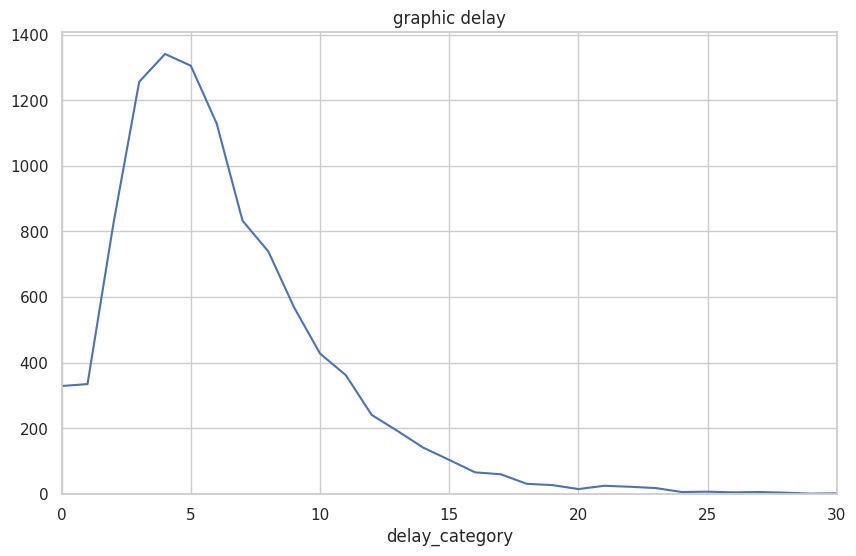

In [977]:
counts = df['delay_category'].value_counts()

plt.figure(figsize=(10, 6))
sns.lineplot(x=counts.index, y=counts.values)
#add limite to x axe
plt.xlim(0, 30)
#add limite to y axe
plt.ylim(0)
#add title to the graphic
plt.title("graphic delay")
#show graphic
plt.show()

graphic delay
USE : print a graphic delay (line graph)
PARAMS : df (dataset)
RETURN : line graph of "delay"

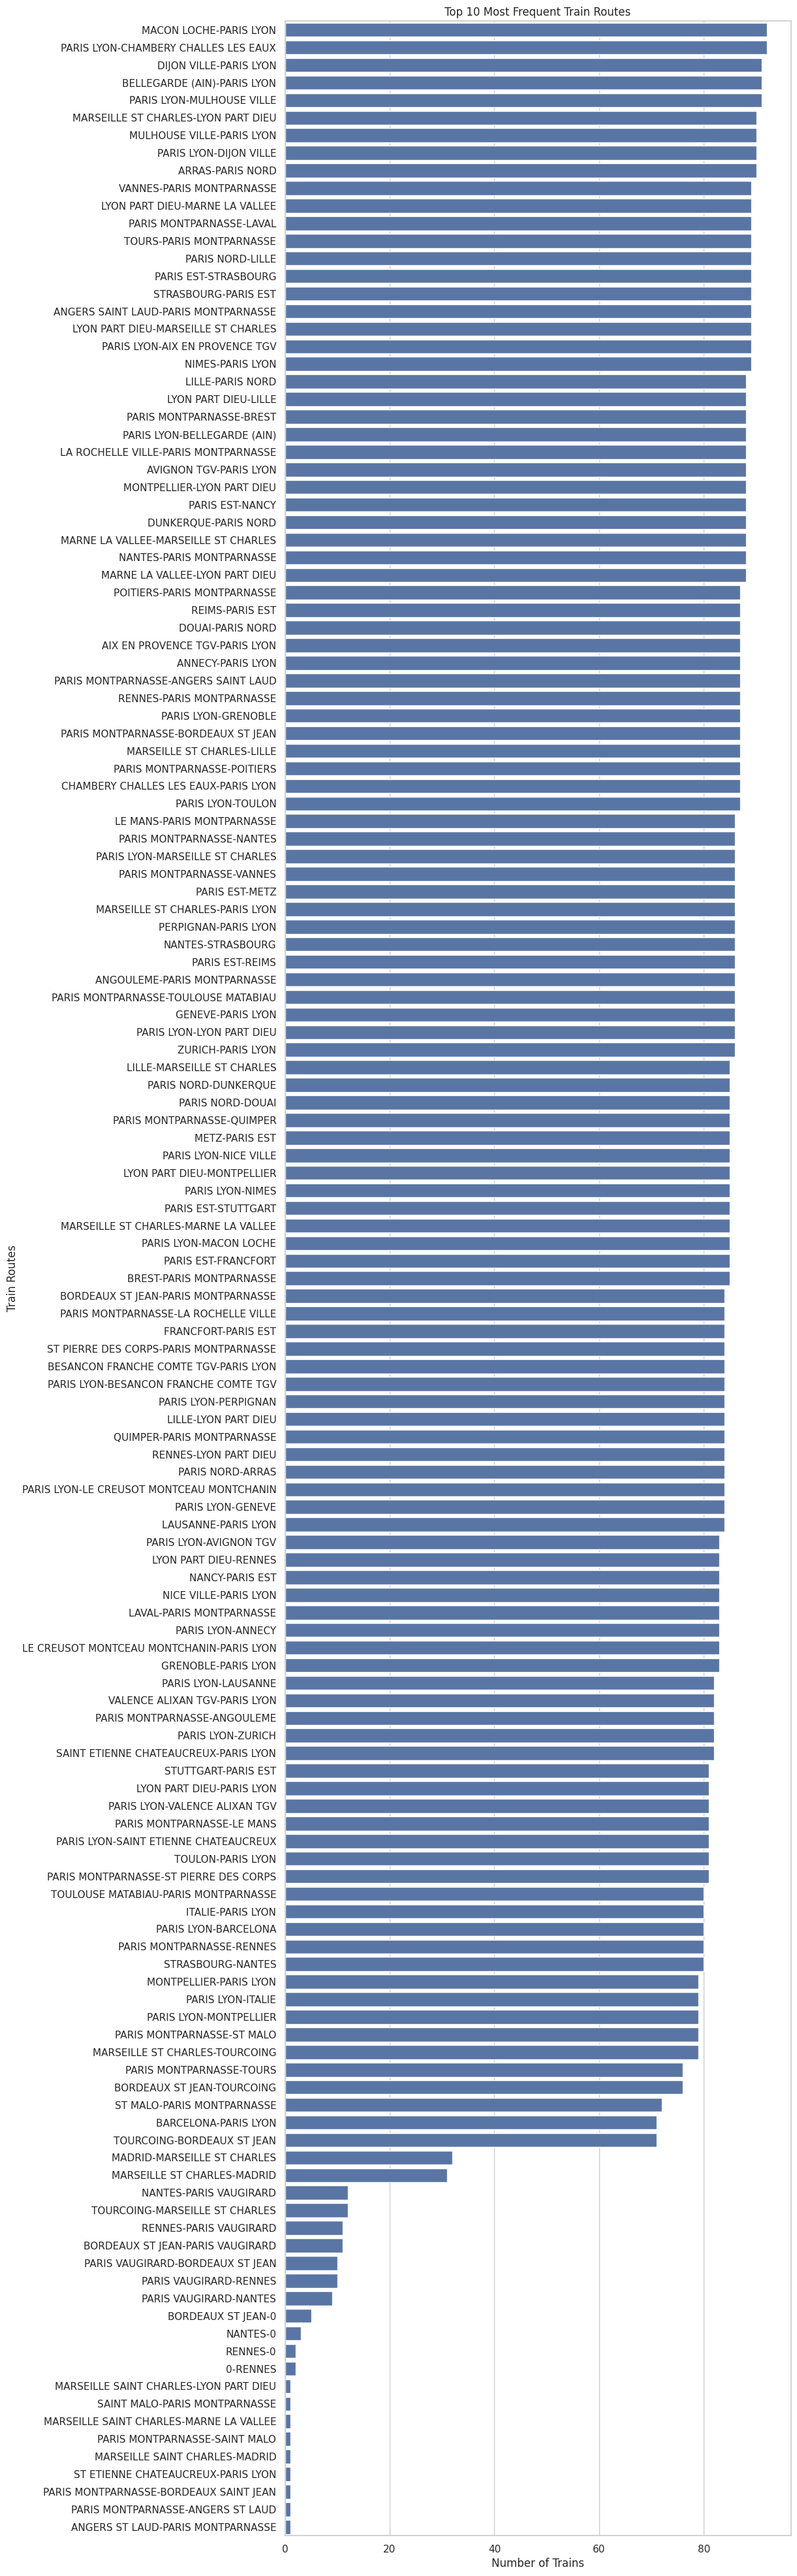

In [978]:
sort_route = df['route'].value_counts().index
plt.figure(figsize=(10, 50))
sns.countplot(data=df, y='route', order=sort_route)
plt.title("Top 10 Most Frequent Train Routes")
plt.xlabel("Number of Trains")
plt.ylabel("Train Routes")
plt.show()

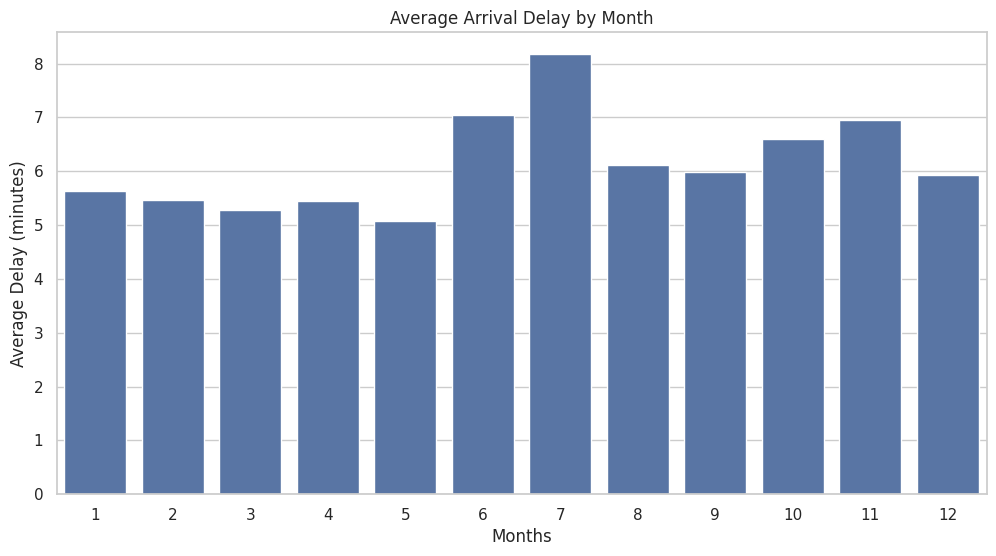

In [979]:
monthly_delay = df.groupby('Month')['Average delay of all trains at arrival'].mean()
plt.figure(figsize=(12, 6))
sns.barplot(x=monthly_delay.index, y=monthly_delay.values)
plt.title("Average Arrival Delay by Month")
plt.xlabel("Months")
plt.ylabel("Average Delay (minutes)")
plt.show()

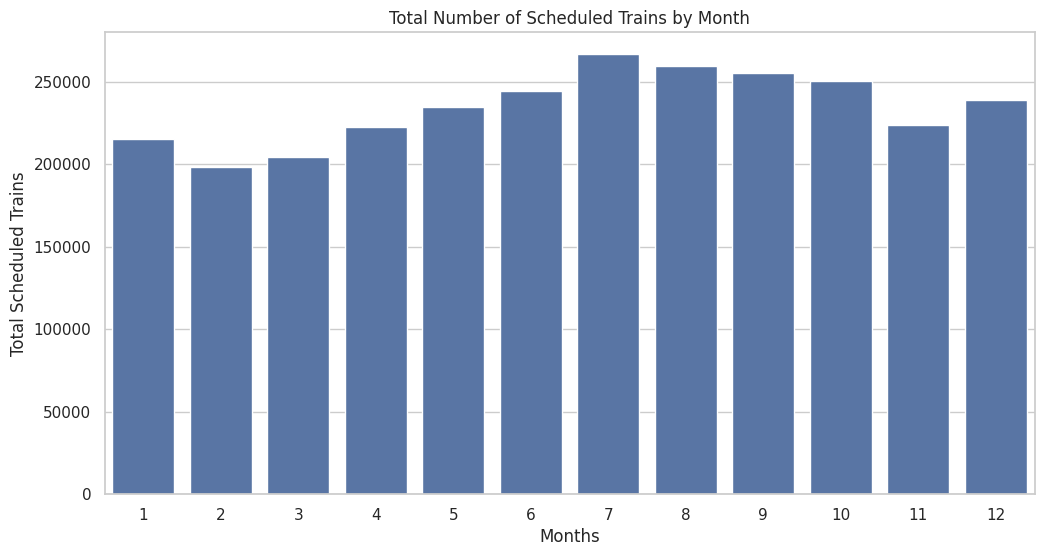

In [980]:
monthly_train_count = df.groupby('Month')['Number of scheduled trains'].sum()
plt.figure(figsize=(12, 6))
sns.barplot(x=monthly_train_count.index, y=monthly_train_count.values)
plt.title("Total Number of Scheduled Trains by Month")
plt.xlabel("Months")
plt.ylabel("Total Scheduled Trains")
plt.show()

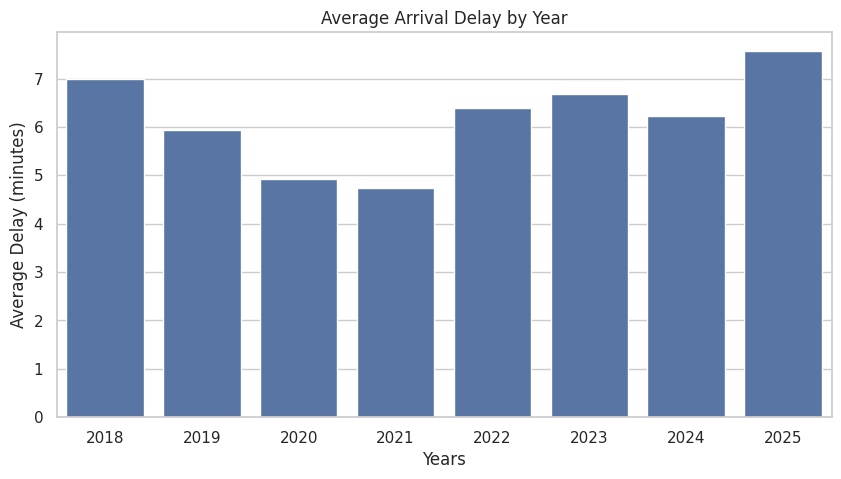

In [981]:
yearly_delay = df.groupby('Year')['Average delay of all trains at arrival'].mean()
plt.figure(figsize=(10, 5))
sns.barplot(x=yearly_delay.index, y=yearly_delay.values)
plt.title("Average Arrival Delay by Year")
plt.xlabel("Years")
plt.ylabel("Average Delay (minutes)")
plt.show()

In [982]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
def plot_delay_dispersion(dataset, graph, titre, couleur):
    sns.scatterplot(
        data=dataset, 
        x='Average delay of all trains at departure', 
        y='Average delay of all trains at arrival',
        color=couleur, 
        alpha=0.6,
        ax = graph
    )
    graph.set_title(titre, fontweight='bold')
    graph.set_xlabel("late departure")
    graph.set_ylabel("late arrived")

df_no_clean = pd.read_csv("dataset.csv", sep=";")

for col in ['Average delay of all trains at departure', 'Average delay of all trains at arrival']:
    #convert columns to a str type
    df_no_clean[col] = df_no_clean[col].astype("string")
    #replace all ',' to '.' to transform into numeric
    df_no_clean[col] = df_no_clean[col].str.replace(',', '.')
    #Remove all the "min" characters so that you can then convert to numeric without any problems.
    df_no_clean[col] = df_no_clean[col].str.replace(' min', '')
    #Remove all the "%" characters so that you can then convert to numeric without any problems.
    df_no_clean[col] = df_no_clean[col].str.replace('%', '')
    #Converted the column to numeric type (string to numeric)
    df_no_clean[col] = pd.to_numeric(df_no_clean[col], errors='coerce')
def scatterplot_graphique(df_before, df_after):
    fig = plt.figure(figsize=(14, 5))
    ax1 = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    plot_delay_dispersion(df_before, ax1, "Before cleaning", "#e74c3c")
    plot_delay_dispersion(df_after, ax2, "After cleaning", "#2ecc71")
    plt.tight_layout()
    plt.show()